**QSM FINAL PROJECT BATTERY AND SUBSIDY CODE**

In [ ]:
import sys

if "google.colab" in sys.modules:
    !wget -q https://raw.githubusercontent.com/IDAES/idaes-pse/main/scripts/colab_helper.py
    import colab_helper
    colab_helper.install_idaes()
    colab_helper.install_ipopt()

Installing idaes via pip...
idaes was successfully installed
idaes, version 2.10.0


Running idaes get-extensions to install Ipopt, k_aug, and more...
Checking solver versions:
Ipopt 3.13.2 (x86_64-pc-linux-gnu), ASL(20190605)



[K_AUG] 0.1.0, Part of the IDAES PSE framework
Please visit https://idaes.org/ (x86_64-pc-linux-gnu), ASL(20190605)



Couenne 0.5.8 -- an Open-Source solver for Mixed Integer Nonlinear Optimization
Mailing list: couenne@list.coin-or.org
Instructions: http://www.coin-or.org/Couenne
couenne (x86_64-pc-linux-gnu), ASL(20190605)



Bonmin 1.8.8 using Cbc 2.10.10 and Ipopt 3.13.2
bonmin (x86_64-pc-linux-gnu), ASL(20190605)



Ipopt 3.13.3 (x86_64-pc-linux-gnu), ASL(20190605)



1.0 dot_1' (x86_64-pc-linux-gnu), ASL(20190605)





In [ ]:
!which ipopt
!ipopt -v

from pyomo.environ import SolverFactory
SolverFactory("ipopt").available()

/root/.idaes/bin//ipopt
Ipopt 3.13.2 (x86_64-pc-linux-gnu), ASL(20190605)



True

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pyomo.environ import *

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
dirpath = '/content/drive/MyDrive/qsm3data'

Mounted at /content/drive


In [ ]:
TECHS = ["hydronuc", "gas1", "gas2", "gas3", "wind", "solar"]
INV_TECHS = ["battery", "solar", "wind"]
RES_TECHS = ["wind", "solar"]

In [ ]:
def load_and_prepare(dirpath: str):

    dfclust = pd.read_csv(f"{dirpath}/data_jaere_week.csv")
    tech = pd.read_csv(f"{dirpath}/data_technology_simple.csv")

    # Hydro + nuclear as baseload
    dfclust["hydronuc"] = dfclust["hydro"] + dfclust["nuclear"]

    # Re-scaling
   # dfclust["weights"] = 8.76 * dfclust["weights"] / dfclust["weights"].sum() ##CHECK WHERE THE WEIGHTS ARE FROM

    dfclust["weights"] = 0.052143

    # Calibrate demand curve: demand = a - b * price
    elas = np.array([0.1, 0.2, 0.5, 0.3])
    dfclust["b"] = elas[2] * dfclust["demand"] / dfclust["price"]
    dfclust["b"] = dfclust["b"].mean()  # constant slope across t
    dfclust["a"] = dfclust["demand"] + dfclust["b"] * dfclust["price"]

    # Calibrate imports: imports = am + bm * price
    dfclust["bm"] = elas[3] * dfclust["imports"] / dfclust["price"]
    dfclust["am"] = dfclust["imports"] - dfclust["bm"] * dfclust["price"]

    # Set index names for tech
    tech.index = ["hydronuc","gas1","gas2","gas3","wind","solar"]

    return dfclust, tech

dfclust, tech = load_and_prepare(dirpath)


In [ ]:
dfclust

,index,year,month,day,hour,price,nuclear,imports,hydro,wind_cap,solar_cap,demand,hydronuc,weights,b,a,bm,am
0,1,2014,3,17,1,31.069120,1.126,8.177,0.525,0.535727,0.0,20.875000,1.651,0.052143,0.275346,29.429752,0.078956,5.7239
1,2,2014,3,17,2,28.582167,1.090,8.017,0.562,0.494422,0.0,20.361000,1.652,0.052143,0.275346,28.230979,0.084147,5.6119
2,3,2014,3,17,3,24.560083,1.085,7.923,0.557,0.501155,0.0,20.003000,1.642,0.052143,0.275346,26.765516,0.096779,5.5461
3,4,2014,3,17,4,24.368763,1.082,8.279,0.527,0.532791,0.0,19.924000,1.609,0.052143,0.275346,26.633836,0.101921,5.7953
4,5,2014,3,17,5,26.686039,1.082,8.317,0.586,0.530245,0.0,20.334000,1.668,0.052143,0.275346,27.681889,0.093498,5.8219
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
163,164,2014,3,23,20,64.155182,1.111,7.781,2.055,0.465086,0.0,25.587000,3.166,0.052143,0.275346,43.251860,0.036385,5.4467
164,165,2014,3,23,21,61.210667,1.104,7.727,1.791,0.478578,0.0,26.180000,2.895,0.052143,0.275346,43.034100,0.037871,5.4089
165,166,2014,3,23,22,55.687649,1.092,7.669,1.467,0.464030,0.0,25.088999,2.559,0.052143,0.275346,40.422359,0.041314,5.3683
166,167,2014,3,23,23,50.360706,1.089,6.973,1.091,0.454409,0.0,23.181000,2.180,0.052143,0.275346,37.047609,0.041538,4.8811


In [ ]:
tech["F"]=0 ##investment into each technology
tech.at["battery","F"] = 130
tech.at["solar","F"] = 90
tech.at["wind","F"] = 120

In [ ]:
tech["renewable"] = 0
tech.at["wind","renewable"] = 1
tech.at["solar","renewable"] = 1

In [ ]:
tech

,techname,heatrate,heatrate2,capUB,thermal,e,e2,c,c2,F,renewable
hydronuc,Hydro/Nuclear,10.000000,0.000000,1.000,0.0,0.000000,0.000000,10.000000,0.000000,0.0,0
gas1,Existing 1,6.671990,0.092912,11.500,1.0,0.360184,0.004886,23.351965,0.325193,0.0,0
gas2,Existing 2,9.794118,0.286247,14.500,1.0,0.546134,0.011078,34.279413,1.001866,0.0,0
gas3,Existing 3,13.818120,20.535160,0.578,1.0,0.816768,0.234476,48.363420,71.873060,0.0,0
wind,Wind,0.000000,0.000000,100.000,0.0,0.000000,0.000000,0.000000,0.000000,120.0,1
solar,Solar,0.000000,0.000000,100.000,0.0,0.000000,0.000000,0.000000,0.000000,90.0,1
battery,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,130.0,0


In [ ]:
def clear_market_min_batt(data, tech,
                          tax=0.0,
                          subsidy=0.0,
                          battery_subsidy=0.0,
                          battery_on=True,
                          solver_name="ipopt",
                          Kmax=80):

    T = len(data)

    # =========================
    # Technology lookups
    # =========================
    c     = {k: float(tech.at[k, "c"])  for k in TECHS}
    c2    = {k: float(tech.at[k, "c2"]) for k in TECHS}

    capUB = {k: float(tech.at[k, "capUB"])
             for k in ["gas1", "gas2", "gas3"]
             if "capUB" in tech.columns and k in tech.index}

    e = {k: float(tech.at[k, "e"]) for k in TECHS} \
        if "e" in tech.columns else {k: 0.0 for k in TECHS}

    renewable_flag = {k: float(tech.at[k, "renewable"]) for k in TECHS} \
        if "renewable" in tech.columns else {k: 0.0 for k in TECHS}

    battery_flag = {k: 0.0 for k in INV_TECHS}
    battery_flag["battery"] = 1.0

    # =========================
    # Battery structural parameters
    # =========================
    F_bar = 2.5      # fixed cost per unit of battery capacity
    S_bar = 10.0     # storage size per unit of investment
    S0 = 0.0

    # =========================
    # Model
    # =========================
    m = ConcreteModel()

    m.T = RangeSet(0, T-1)
    m.I = Set(initialize=TECHS, ordered=False)
    m.J = Set(initialize=INV_TECHS, ordered=False)

    m.price   = Var(m.T, domain=Reals)
    m.demand  = Var(m.T, domain=Reals)
    m.imports = Var(m.T, domain=Reals)

    m.q     = Var(m.T, m.I, domain=NonNegativeReals)
    m.costs = Var(m.T, domain=Reals)
    m.gs    = Var(m.T, domain=Reals)

    # =========================
    # Battery variables
    # =========================
    m.S = Var(m.T, domain=NonNegativeReals)
    m.c = Var(m.T, domain=NonNegativeReals)
    m.d = Var(m.T, domain=NonNegativeReals)

    m.K = Var(m.J, bounds=(0.0, float(Kmax)))

    # =========================
    # Turn battery OFF cleanly
    # =========================
    if not battery_on:
        for t in m.T:
            m.S[t].fix(0.0)
            m.c[t].fix(0.0)
            m.d[t].fix(0.0)
        m.K["battery"].fix(0.0)

    # =========================
    # Objective
    # =========================
    m.obj = Objective(
        expr=sum(data.weights[t] * (m.gs[t] - m.costs[t]) for t in m.T)
        - sum(
            (
                (F_bar if j == "battery" else tech.at[j, "F"])
                - battery_subsidy * battery_flag[j]
            ) * m.K[j]
            for j in m.J
        ),
        sense=maximize
    )

    # =========================
    # Market clearing
    # =========================
    m.demand_curve = Constraint(
        m.T,
        expr={t: m.demand[t] == data.a[t] - data.b[t] * m.price[t]
              for t in m.T}
    )

    m.imports_curve = Constraint(
        m.T,
        expr={t: m.imports[t] == data.am[t] + data.bm[t] * m.price[t]
              for t in m.T}
    )

    m.market_clear = Constraint(
        m.T,
        expr={
            t: m.demand[t] + m.c[t]
               == sum(m.q[t, k] for k in m.I)
               + m.imports[t]
               + m.d[t]
            for t in m.T
        }
    )

    # =========================
    # Surplus
    # =========================
    m.surplus_def = Constraint(
        m.T,
        expr={
            t: m.gs[t]
               == (data.a[t] - m.demand[t]) * m.demand[t] / data.b[t]
               + (m.demand[t]**2) / (2.0 * data.b[t])
            for t in m.T
        }
    )

    # =========================
    # Costs
    # =========================
    m.cost_def = Constraint(
        m.T,
        expr={
            t: m.costs[t]
               == sum(
                   (
                       c[k]
                       + c2[k] * m.q[t, k]
                       + tax * e[k]
                       - subsidy * renewable_flag[k]
                   ) * m.q[t, k]
                   for k in m.I
               )
               + (m.imports[t] - data.am[t])**2
                 / (2.0 * data.bm[t])
            for t in m.T
        }
    )

    # =========================
    # Capacity constraints
    # =========================
    m.cap_hydronuc = Constraint(
        m.T,
        expr={t: m.q[t, "hydronuc"] <= data.hydronuc[t]
              for t in m.T}
    )

    if capUB:
        m.cap_gas = Constraint(
            m.T,
            Set(initialize=list(capUB)),
            expr={(t, k): m.q[t, k] <= capUB[k]
                  for t in m.T for k in capUB}
        )

    m.cap_wind = Constraint(
        m.T,
        expr={t: m.q[t, "wind"]
              <= m.K["wind"] * data.wind_cap[t]
              for t in m.T}
    )

    m.cap_solar = Constraint(
        m.T,
        expr={t: m.q[t, "solar"]
              <= m.K["solar"] * data.solar_cap[t]
              for t in m.T}
    )

    # =========================
    # Battery constraints (only if ON)
    # =========================
    if battery_on:

        m.batt_stock = Constraint(
            m.T,
            expr={
                t: m.S[t]
                   == (S0 if t == 0 else m.S[t-1])
                   + 0.9 * m.c[t]
                   - m.d[t]
                for t in m.T
            }
        )

        m.batt_cap = Constraint(
            m.T,
            expr={t: m.S[t]
                  <= S_bar * m.K["battery"]
                  for t in m.T}
        )

        m.batt_charge_cap = Constraint(
            m.T,
            expr={t: m.c[t]
                  <= m.K["battery"] / 4.0
                  for t in m.T}
        )

        m.batt_discharge_cap = Constraint(
            m.T,
            expr={t: m.d[t]
                  <= m.K["battery"] / 4.0
                  for t in m.T}
        )

    # =========================
    # Solve
    # =========================
    res = SolverFactory(solver_name).solve(m, tee=False)
    term = str(res.solver.termination_condition)

    if term.lower() in (
        "optimal", "locallyoptimal",
        "locally_optimal", "locally optimal"
    ):

        price   = np.array([value(m.price[t]) for t in m.T])
        demand  = np.array([value(m.demand[t]) for t in m.T])
        imports = np.array([value(m.imports[t]) for t in m.T])

        q = {k: np.array([value(m.q[t, k]) for t in m.T])
             for k in TECHS}

        S    = np.array([value(m.S[t]) for t in m.T])
        cbat = np.array([value(m.c[t]) for t in m.T])
        dbat = np.array([value(m.d[t]) for t in m.T])

        w_arr = data["weights"].to_numpy()
        avg_price = float(np.sum(price * w_arr) / np.sum(w_arr))

        emissions = sum(
            w_arr[t] * sum(e[k] * q[k][t] for k in TECHS)
            for t in range(T)
        )

        subsidy_cost = subsidy * sum(
            w_arr[t] * sum(renewable_flag[k] * q[k][t]
                           for k in TECHS)
            for t in range(T)
        )

        battery_subsidy_cost = (
            battery_subsidy * value(m.K["battery"])
        )

        welfare = (
    value(m.obj)
    - subsidy_cost
    - battery_subsidy_cost
    + tax * emissions
    - 51 * emissions
)

        return {
            "status": term,
            "avg_price": avg_price,
            "price": price,
            "demand": demand,
            "objective": value(m.obj),
            "welfare": welfare,
            "imports": imports,
            "q": q,
            "emissions": emissions,
            "subsidy_cost": subsidy_cost,
            "battery_subsidy_cost": battery_subsidy_cost,
            "stock": S,
            "charge": cbat,
            "discharge": dbat,
            "investment": {k: value(m.K[k]) for k in INV_TECHS}
        }

    return {"status": term}

In [ ]:
# ==============================
# Run Policy Scenarios
# ==============================

cases = {}

cases["No Policy, No Battery"] = clear_market_min_batt(
    dfclust, tech,
    tax=0.0,
    subsidy=0.0,
    battery_subsidy=0.0,
  battery_on=False
)

cases["No Policy, Battery"] = clear_market_min_batt(
    dfclust, tech,
    tax=0.0,
    subsidy=0.0,
    battery_subsidy=0.0,
  battery_on=True
)

cases["Renewable Subsidy Only"] = clear_market_min_batt(
    dfclust, tech,
    tax=0.0,
    subsidy=27,
    battery_subsidy=0.0
)

cases["Battery Subsidy Only"] = clear_market_min_batt(
    dfclust, tech,
    tax=0.0,
    subsidy=0.0,
    battery_subsidy=100
)

cases["Renewable + Battery Subsidy"] = clear_market_min_batt(
    dfclust, tech,
    tax=0.0,
    subsidy=27,
    battery_subsidy=100
)

cases["Renewable + Battery + Carbon Tax"] = clear_market_min_batt(
    dfclust, tech,
    tax=51.0,
    subsidy=27,
    battery_subsidy=100
)

cases["Carbon Tax Only"] = clear_market_min_batt(
    dfclust, tech,
    tax=51.0,
    subsidy=0.0,
    battery_subsidy=0.0
)

In [ ]:
cases["No Policy, No Battery"]["welfare"]

np.float64(13232.502403336026)

In [ ]:
cases["Renewable + Battery + Carbon Tax"]["welfare"]

np.float64(14105.338230334575)

In [ ]:
cases["Carbon Tax Only"]["welfare"]

np.float64(14105.33823293312)

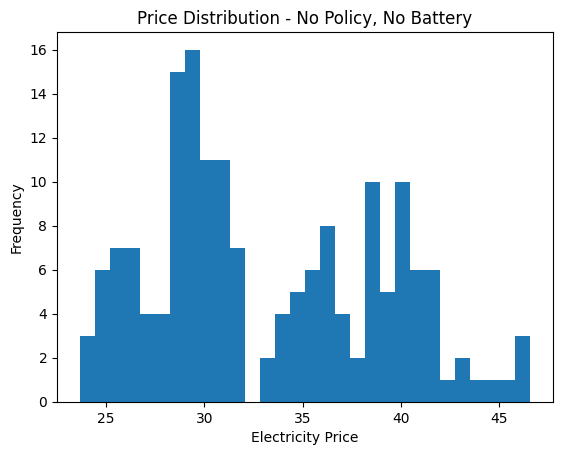

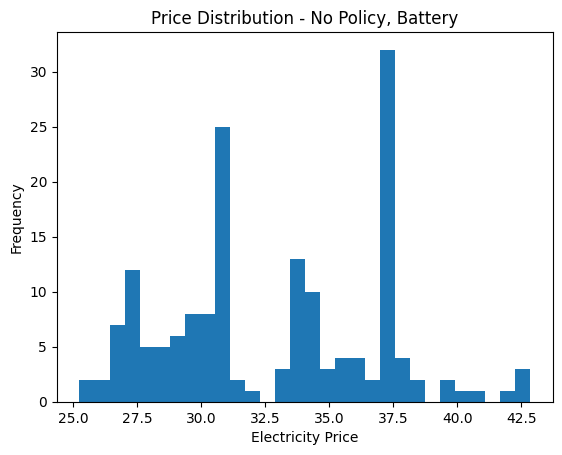

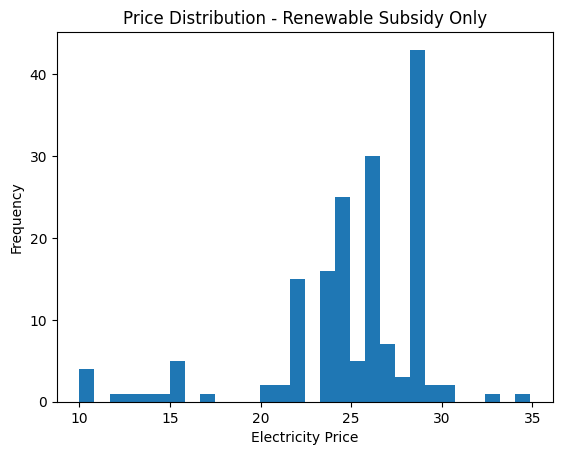

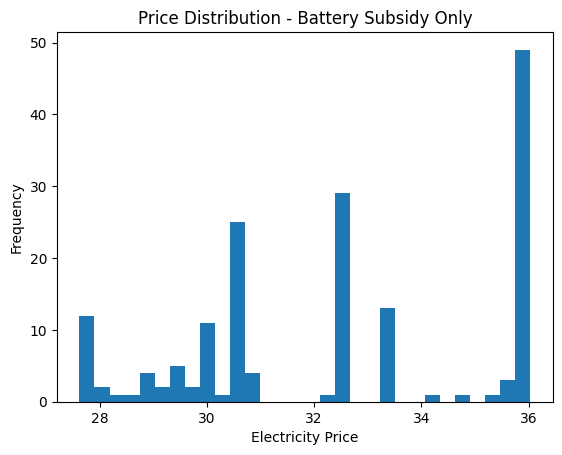

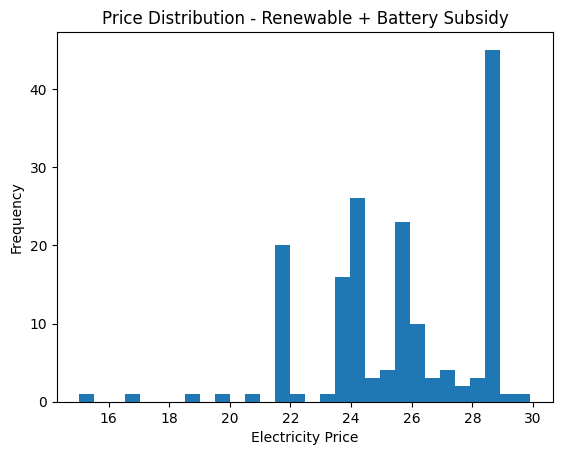

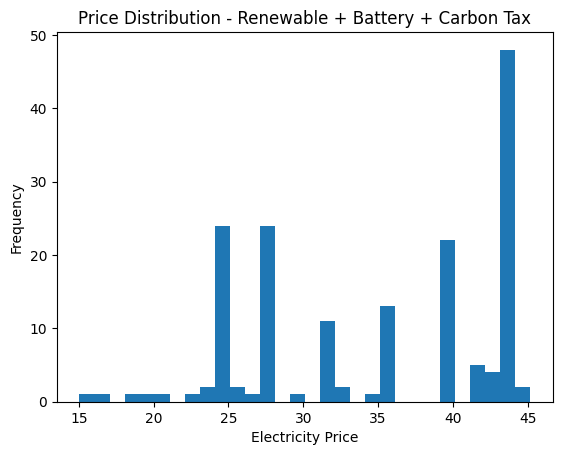

In [ ]:
import matplotlib.pyplot as plt

for name, result in cases.items():
    if result["status"].lower() in ("optimal", "locallyoptimal", "locally_optimal", "locally optimal"):
        plt.figure()
        plt.hist(result["price"], bins=30)
        plt.title(f"Price Distribution - {name}")
        plt.xlabel("Electricity Price")
        plt.ylabel("Frequency")
        plt.show()

In [ ]:
import pandas as pd

welfare_table = pd.DataFrame({
    "Case": list(cases.keys()),
    "Welfare": [cases[k]["welfare"] for k in cases],
    "Average Price": [cases[k]["avg_price"] for k in cases],
    "Emissions": [cases[k]["emissions"] for k in cases],
   # "Renewable Subsidy Cost": [cases[k]["subsidy_cost"] for k in cases],
  #  "Battery Subsidy Cost": [cases[k]["battery_subsidy_cost"] for k in cases],
    "Solar": [cases[k]["investment"]["solar"] for k in cases],
    "Wind": [cases[k]["investment"]["wind"] for k in cases],
    "Battery": [cases[k]["investment"]["battery"] for k in cases],
    "Renewable Subsidy Cost": [cases[k]["subsidy_cost"] for k in cases],
    "Battery Subsidy Cost": [cases[k]["battery_subsidy_cost"] for k in cases]
})

welfare_table

,Case,Welfare,Average Price,Emissions,Solar,Wind,Battery,Renewable Subsidy Cost,Battery Subsidy Cost
0,"No Policy, No Battery",13232.502403,34.002711,2.714498e+01,0.0,24.308420,0.000000,0.000000,0.0
1,"No Policy, Battery",13378.052383,33.156034,2.541114e+01,0.0,25.576949,19.279278,0.000000,0.0
2,Renewable Subsidy Only,12533.468056,6.522060,6.234879e-10,0.0,70.099207,74.824570,7131.841428,0.0
3,Battery Subsidy Only,13303.792745,32.701815,2.461214e+01,0.0,26.131692,80.000000,0.000000,8000.0
4,Renewable + Battery Subsidy,12479.943866,6.262800,2.870932e-12,0.0,70.605238,80.000000,7183.324664,8000.0
5,Renewable + Battery + Carbon Tax,12479.943872,6.262800,0.000000e+00,0.0,70.605238,80.000000,7183.324665,8000.0
6,Carbon Tax Only,14107.755375,33.816569,2.492755e+00,0.0,41.182792,42.304174,0.000000,0.0


In [ ]:
# ============================================================
# Extended Scenario Diagnostics Table
# ============================================================
# This table collects policy parameters and endogenous outcomes
# in one place to make cross-scenario comparisons transparent.

# Policy parameters used in each scenario — stored manually here
# to keep the diagnostics self-contained and readable.
scenario_params = {
    "No Policy, No Battery":            {"tax": 0.0,  "subsidy": 0.0,   "battery_subsidy": 0.0,   "battery_on": False},
    "Renewable Subsidy Only":           {"tax": 0.0,  "subsidy": 27.0, "battery_subsidy": 0.0,   "battery_on": True},
    "Battery Subsidy Only":             {"tax": 0.0,  "subsidy": 0.0,   "battery_subsidy": 140.0, "battery_on": True},
    "Renewable + Battery Subsidy":      {"tax": 0.0,  "subsidy": 27.0, "battery_subsidy": 140.0, "battery_on": True},
    "Renewable + Battery + Carbon Tax": {"tax": 51.0, "subsidy": 27.0,  "battery_subsidy": 140.0, "battery_on": True},
}

diag_rows = []

for name, result in cases.items():

    if result.get("status", "").lower() not in ("optimal", "locallyoptimal", "locally_optimal", "locally optimal"):
        continue

    params = scenario_params.get(name, {})
    inv    = result.get("investment", {})   # Endogenous capacity investments: wind, solar, battery
    w_arr  = dfclust["weights"].to_numpy()

    # --- Weighted average quantities by technology (annualised GWh proxy) ---
    avg_q = {
        k: float(np.sum(result["q"][k] * w_arr))
        for k in TECHS
    }

    # --- Total generation cost (before subsidy), annualised ---
    # Reconstructed as sum of (c*q + c2*q^2) weighted by time period
    total_gen_cost = sum(
        float(np.sum(
            w_arr * (float(tech.at[k, "c"]) * result["q"][k]
                     + float(tech.at[k, "c2"]) * result["q"][k] ** 2)
        ))
        for k in TECHS
    )

    diag_rows.append({
        # --- Policy levers ---
        "Scenario":              name,
        "Carbon Tax":            params.get("tax", "-"),
        "Renewable Subsidy":     params.get("subsidy", "-"),
        "Battery Subsidy":       params.get("battery_subsidy", "-"),
        "Battery On":            params.get("battery_on", "-"),

        # --- Endogenous investment outcomes ---
        "K_wind (GW)":           round(inv.get("wind",    0.0), 3),
        "K_solar (GW)":          round(inv.get("solar",   0.0), 3),
        "K_battery (GWh)":       round(inv.get("battery", 0.0), 3),

        # --- Dispatch summary (annualised weighted avg) ---
        "Avg Q wind":            round(avg_q.get("wind",    0.0), 2),
        "Avg Q solar":           round(avg_q.get("solar",   0.0), 2),
        "Avg Q gas1":            round(avg_q.get("gas1",    0.0), 2),
        "Avg Q gas2":            round(avg_q.get("gas2",    0.0), 2),
        "Avg Q gas3":            round(avg_q.get("gas3",    0.0), 2),

        # --- Price and cost summary ---
        "Avg Price":             round(result["avg_price"], 2),
        "Total Gen Cost":        round(total_gen_cost, 2),
        "Renewable Subsidy Cost":round(result["subsidy_cost"], 2),
        "Battery Subsidy Cost":  round(result["battery_subsidy_cost"], 2),
        "Emissions":             round(result["emissions"], 2),
        "Welfare":               round(result["welfare"], 2),
    })

diag_df = pd.DataFrame(diag_rows).set_index("Scenario")

# Transpose for readability — scenarios as columns, metrics as rows
print("Extended Scenario Diagnostics (transposed: metrics × scenarios)")
print("=" * 80)
diag_df.T

Extended Scenario Diagnostics (transposed: metrics × scenarios)


Scenario,"No Policy, No Battery","No Policy, Battery",Renewable Subsidy Only,Battery Subsidy Only,Renewable + Battery Subsidy,Renewable + Battery + Carbon Tax,Carbon Tax Only
Carbon Tax,0.0,-,0.0,0.0,0.0,51.0,-
Renewable Subsidy,0.0,-,27.0,0.0,27.0,27.0,-
Battery Subsidy,0.0,-,0.0,140.0,140.0,140.0,-
Battery On,False,-,True,True,True,True,-
K_wind (GW),24.308,25.577,40.0,25.721,40.0,40.0,40.0
K_solar (GW),0.0,0.0,10.225,0.0,0.0,0.0,0.0
K_battery (GWh),0.0,19.279,27.997,40.0,40.0,40.0,40.0
Avg Q wind,91.6,96.38,150.72,96.92,150.72,150.72,150.72
Avg Q solar,0.0,0.0,14.32,0.0,0.0,0.0,0.0
Avg Q gas1,53.72,59.04,24.96,61.89,33.62,8.47,8.47


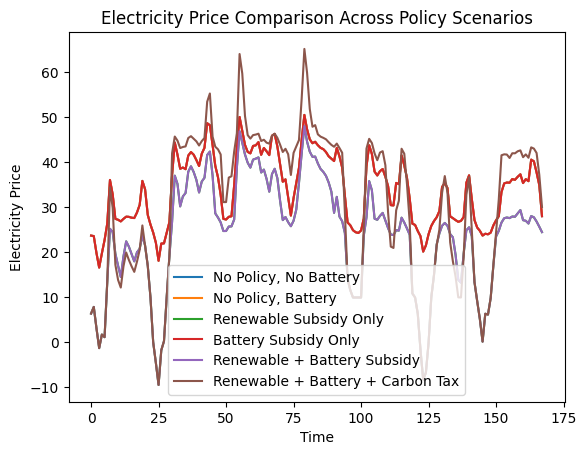

In [ ]:
plt.figure()

for name, result in cases.items():
    if result["status"].lower() in ("optimal", "locallyoptimal", "locally_optimal", "locally optimal"):
        price_series = np.array(result["price"])
        plt.plot(range(len(price_series)), price_series, label=name)

plt.title("Electricity Price Comparison Across Policy Scenarios")
plt.xlabel("Time")
plt.ylabel("Electricity Price")
plt.legend()
plt.show()

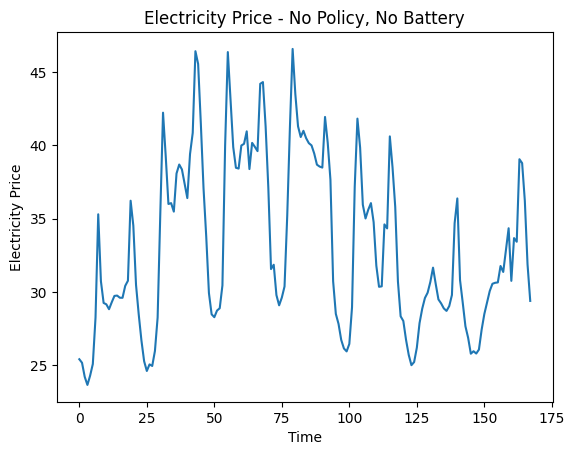

In [ ]:
plt.figure()

result = cases["No Policy, No Battery"]

if result["status"].lower() in ("optimal", "locallyoptimal", "locally_optimal", "locally optimal"):
    price_series = np.array(result["price"])
    plt.plot(range(len(price_series)), price_series)

plt.title("Electricity Price - No Policy, No Battery")
plt.xlabel("Time")
plt.ylabel("Electricity Price")
plt.show()

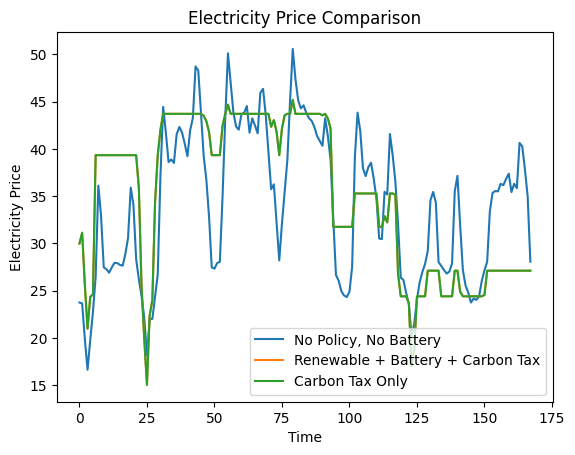

In [ ]:
plt.figure()

case_names = [
    "No Policy, No Battery",
  #  "No Policy, Battery",
 #   "Renewable Subsidy Only",
   # "Battery Subsidy Only",
   # "Renewable + Battery Subsidy",
    "Renewable + Battery + Carbon Tax",
    "Carbon Tax Only"
]

for case in case_names:
    result = cases[case]

    if result["status"].lower() in ("optimal", "locallyoptimal", "locally_optimal", "locally optimal"):
        price_series = np.array(result["price"])
        plt.plot(range(len(price_series)), price_series, label=case)

plt.title("Electricity Price Comparison")
plt.xlabel("Time")
plt.ylabel("Electricity Price")
plt.legend()
plt.show()

In [ ]:
def clear_market_min(data, tech,
                     tax=0.0,
                     subsidy=0.0,
                     solver_name="ipopt",
                     Kmax=50):

    T = len(data)

    # =========================
    # Technology lookups
    # =========================
    c     = {k: float(tech.at[k, "c"])     for k in TECHS}
    c2    = {k: float(tech.at[k, "c2"])    for k in TECHS}
    capUB = {k: float(tech.at[k, "capUB"])
             for k in ["gas1","gas2","gas3"]
             if "capUB" in tech.columns and k in tech.index}

    e = {k: float(tech.at[k, "e"]) for k in TECHS} if "e" in tech.columns else {k: 0.0 for k in TECHS}
    renewable_flag = {k: float(tech.at[k, "renewable"]) for k in TECHS} if "renewable" in tech.columns else {k: 0.0 for k in TECHS}

    # =========================
    # Model
    # =========================
    m = ConcreteModel()

    m.T = RangeSet(0, T-1)
    m.I = Set(initialize=TECHS, ordered=False)
    m.J = Set(initialize=INV_TECHS, ordered=False)

    m.price   = Var(m.T, domain=Reals)
    m.demand  = Var(m.T, domain=Reals)
    m.imports = Var(m.T, domain=Reals)

    m.q     = Var(m.T, m.I, domain=NonNegativeReals)
    m.costs = Var(m.T, domain=Reals)
    m.gs    = Var(m.T, domain=Reals)

    m.K = Var(m.J, bounds=(0.0, float(Kmax)))

    # =========================
    # Objective
    # =========================
    m.obj = Objective(
        expr=sum(data.weights[t] * (m.gs[t] - m.costs[t]) for t in m.T)
             - sum(tech.at[j,"F"] * m.K[j] for j in m.J),
        sense=maximize
    )

    # =========================
    # Market clearing
    # =========================
    m.demand_curve = Constraint(
        m.T,
        expr={t: m.demand[t] == data.a[t] - data.b[t] * m.price[t] for t in m.T}
    )

    m.imports_curve = Constraint(
        m.T,
        expr={t: m.imports[t] == data.am[t] + data.bm[t] * m.price[t] for t in m.T}
    )

    m.market_clear = Constraint(
        m.T,
        expr={
            t: m.demand[t] ==
               sum(m.q[t,k] for k in m.I) + m.imports[t]
            for t in m.T
        }
    )

    # =========================
    # Surplus
    # =========================
    m.surplus_def = Constraint(
        m.T,
        expr={
            t: m.gs[t] ==
               (data.a[t] - m.demand[t]) * m.demand[t] / data.b[t]
               + (m.demand[t]**2) / (2.0 * data.b[t])
            for t in m.T
        }
    )

    # =========================
    # Costs
    # =========================
    m.cost_def = Constraint(
        m.T,
        expr={
            t: m.costs[t] ==
               sum(
                   (
                       c[k]
                       + c2[k] * m.q[t,k]
                       + tax * e[k]
                       - subsidy * renewable_flag[k]
                   ) * m.q[t,k]
                   for k in m.I
               )
               + (m.imports[t] - data.am[t])**2 / (2.0 * data.bm[t])
            for t in m.T
        }
    )

    # =========================
    # Capacity constraints
    # =========================
    m.cap_hydronuc = Constraint(
        m.T,
        expr={t: m.q[t,"hydronuc"] <= data.hydronuc[t] for t in m.T}
    )

    if capUB:
        m.cap_gas = Constraint(
            m.T,
            Set(initialize=list(capUB)),
            expr={(t,k): m.q[t,k] <= capUB[k] for t in m.T for k in capUB}
        )

    m.cap_wind = Constraint(
        m.T,
        expr={t: m.q[t,"wind"] <= m.K["wind"] * data.wind_cap[t] for t in m.T}
    )

    m.cap_solar = Constraint(
        m.T,
        expr={t: m.q[t,"solar"] <= m.K["solar"] * data.solar_cap[t] for t in m.T}
    )

    # =========================
    # Solve
    # =========================
    res = SolverFactory(solver_name).solve(m, tee=False)
    term = str(res.solver.termination_condition)

    if term.lower() in ("optimal", "locallyoptimal", "locally_optimal", "locally optimal"):

        price   = np.array([value(m.price[t]) for t in m.T])
        demand  = np.array([value(m.demand[t]) for t in m.T])
        imports = np.array([value(m.imports[t]) for t in m.T])
        q = {k: np.array([value(m.q[t,k]) for t in m.T]) for k in TECHS}

        w_arr = data["weights"].to_numpy()
        avg_price = float(np.sum(price * w_arr) / np.sum(w_arr))

        emissions = sum(
            w_arr[t] * sum(e[k] * q[k][t] for k in TECHS)
            for t in range(T)
        )

        subsidy_cost = subsidy * sum(
            w_arr[t] * sum(renewable_flag[k] * q[k][t] for k in TECHS)
            for t in range(T)
        )

        welfare = value(m.obj) - subsidy_cost + tax * emissions

        return {
            "status": term,
            "avg_price": avg_price,
            "price": price,
            "demand": demand,
            "objective": value(m.obj),
            "welfare": welfare,
            "imports": imports,
            "q": q,
            "emissions": emissions,
            "subsidy_cost": subsidy_cost,
            "investment": {k: value(m.K[k]) for k in INV_TECHS}
        }

    return {"status": term}

In [ ]:
cases_nobatt = {}

cases_nobatt["No Policy, No Battery"] = clear_market_min(
    dfclust, tech,
    tax=0.0,
    subsidy=0.0
)

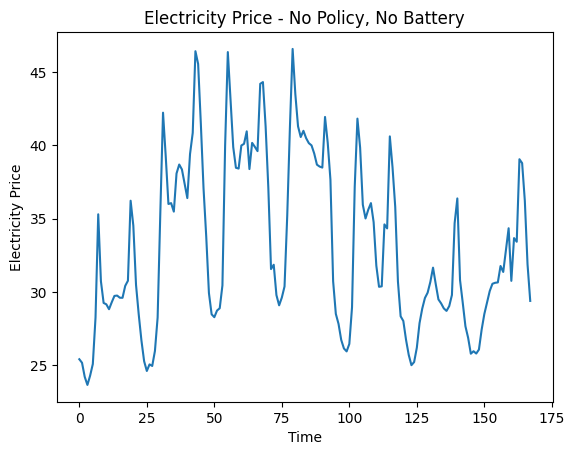

In [ ]:
plt.figure()

result = cases_nobatt["No Policy, No Battery"]

if result["status"].lower() in ("optimal", "locallyoptimal", "locally_optimal", "locally optimal"):
    price_series = np.array(result["price"])
    plt.plot(range(len(price_series)), price_series)

plt.title("Electricity Price - No Policy, No Battery")
plt.xlabel("Time")
plt.ylabel("Electricity Price")
plt.show()

In [ ]:
# ============================================================
# Producer Surplus by Technology and Policy Scenario
# ============================================================
scenario_params_ps = {
    "No Policy, No Battery":            {"tax": 0.0,  "subsidy": 0.0},
    "No Policy, Battery":               {"tax": 0.0,  "subsidy": 0.0},
    "Renewable Subsidy Only":           {"tax": 0.0,  "subsidy": 27.0},
    "Battery Subsidy Only":             {"tax": 0.0,  "subsidy": 0.0},
    "Renewable + Battery Subsidy":      {"tax": 0.0,  "subsidy": 27.0},
    "Renewable + Battery + Carbon Tax": {"tax": 51.0, "subsidy": 27.0},
}

w_arr = dfclust["weights"].to_numpy()
ps_rows = []

for scenario_name, result in cases.items():
    if result.get("status", "").lower() not in ("optimal", "locallyoptimal", "locally_optimal", "locally optimal"):
        continue

    params = scenario_params_ps.get(scenario_name, {"tax": 0.0, "subsidy": 0.0})
    price = np.array(result["price"])

    for k in TECHS:
        q_k = np.array(result["q"][k])
        c_k = float(tech.at[k, "c"])
        c2_k = float(tech.at[k, "c2"])
        e_k = float(tech.at[k, "e"]) if "e" in tech.columns else 0.0
        ren_k = float(tech.at[k, "renewable"]) if "renewable" in tech.columns else 0.0

        revenue = price * q_k
        variable_cost = c_k * q_k + c2_k * (q_k ** 2)
        policy_adjustment = params["subsidy"] * ren_k * q_k - params["tax"] * e_k * q_k

        producer_surplus = float(np.sum(w_arr * (revenue - variable_cost + policy_adjustment)))

        ps_rows.append({
            "Scenario": scenario_name,
            "Technology": k,
            "Producer Surplus": producer_surplus
        })

producer_surplus_long = pd.DataFrame(ps_rows)
producer_surplus_table = producer_surplus_long.pivot(index="Technology", columns="Scenario", values="Producer Surplus")

print("Producer Surplus by Technology and Scenario")
producer_surplus_table

Producer Surplus by Technology and Scenario


Scenario,Battery Subsidy Only,"No Policy, Battery","No Policy, No Battery",Renewable + Battery + Carbon Tax,Renewable + Battery Subsidy,Renewable Subsidy Only
Technology,,,,,,
gas1,5.522951e+02,5.954261e+02,6.501158e+02,8.412207,7.367600e+01,85.787418
gas2,2.039102e+00,1.066324e+01,2.994888e+01,0.000002,1.827892e-07,0.004944
gas3,8.108655e-07,8.564811e-07,8.241743e-07,0.000005,1.416552e-06,0.000002
hydronuc,4.076190e+02,4.174417e+02,4.285402e+02,452.071218,2.825663e+02,275.671870
solar,1.871513e-06,1.949454e-06,1.969565e-06,0.000005,3.349577e-06,0.000004
wind,2.177819e+03,2.208048e+03,2.213701e+03,9031.016298,7.815428e+03,7675.552832


In [ ]:
# ============================================================
# Save all plots (PNG) and tables (CSV) to results folder
# ============================================================
from pathlib import Path

results_dir = Path(dirpath) / "results"
results_dir.mkdir(parents=True, exist_ok=True)

valid_terms = ("optimal", "locallyoptimal", "locally_optimal", "locally optimal")

def _slug(text: str) -> str:
    return "".join(ch.lower() if ch.isalnum() else "_" for ch in text).strip("_")

saved_files = []

# 1) Histogram per policy scenario
for name, result in cases.items():
    if result.get("status", "").lower() in valid_terms:
        fig, ax = plt.subplots()
        ax.hist(result["price"], bins=30)
        ax.set_title(f"Price Distribution - {name}")
        ax.set_xlabel("Electricity Price")
        ax.set_ylabel("Frequency")
        out = results_dir / f"price_distribution_{_slug(name)}.png"
        fig.tight_layout()
        fig.savefig(out, dpi=300, bbox_inches="tight")
        plt.close(fig)
        saved_files.append(out.name)

# 2) Electricity price comparison across all policy scenarios
fig, ax = plt.subplots()
for name, result in cases.items():
    if result.get("status", "").lower() in valid_terms:
        ax.plot(range(len(result["price"])), np.array(result["price"]), label=name)
ax.set_title("Electricity Price Comparison Across Policy Scenarios")
ax.set_xlabel("Time")
ax.set_ylabel("Electricity Price")
ax.legend()
out = results_dir / "electricity_price_comparison_all_scenarios.png"
fig.tight_layout()
fig.savefig(out, dpi=300, bbox_inches="tight")
plt.close(fig)
saved_files.append(out.name)

# 3) Electricity price: no policy, no battery (from cases)
if "No Policy, No Battery" in cases and cases["No Policy, No Battery"].get("status", "").lower() in valid_terms:
    fig, ax = plt.subplots()
    ps = np.array(cases["No Policy, No Battery"]["price"])
    ax.plot(range(len(ps)), ps)
    ax.set_title("Electricity Price - No Policy, No Battery")
    ax.set_xlabel("Time")
    ax.set_ylabel("Electricity Price")
    out = results_dir / "electricity_price_no_policy_no_battery_cases.png"
    fig.tight_layout()
    fig.savefig(out, dpi=300, bbox_inches="tight")
    plt.close(fig)
    saved_files.append(out.name)

# 4) Electricity price comparison (selected cases)
selected_case_names = [
    "No Policy, No Battery",
    "No Policy, Battery",
    "Battery Subsidy Only",
]
fig, ax = plt.subplots()
for case in selected_case_names:
    if case in cases and cases[case].get("status", "").lower() in valid_terms:
        ps = np.array(cases[case]["price"])
        ax.plot(range(len(ps)), ps, label=case)
ax.set_title("Electricity Price Comparison")
ax.set_xlabel("Time")
ax.set_ylabel("Electricity Price")
ax.legend()
out = results_dir / "electricity_price_comparison_selected_cases.png"
fig.tight_layout()
fig.savefig(out, dpi=300, bbox_inches="tight")
plt.close(fig)
saved_files.append(out.name)

# 5) Electricity price: no policy, no battery (from cases_nobatt)
if "No Policy, No Battery" in cases_nobatt and cases_nobatt["No Policy, No Battery"].get("status", "").lower() in valid_terms:
    fig, ax = plt.subplots()
    ps = np.array(cases_nobatt["No Policy, No Battery"]["price"])
    ax.plot(range(len(ps)), ps)
    ax.set_title("Electricity Price - No Policy, No Battery")
    ax.set_xlabel("Time")
    ax.set_ylabel("Electricity Price")
    out = results_dir / "electricity_price_no_policy_no_battery_cases_nobatt.png"
    fig.tight_layout()
    fig.savefig(out, dpi=300, bbox_inches="tight")
    plt.close(fig)
    saved_files.append(out.name)

# 6) Tables to CSV
if "welfare_table" in globals():
    out = results_dir / "welfare_table.csv"
    welfare_table.to_csv(out, index=False)
    saved_files.append(out.name)

if "diag_df" in globals():
    out1 = results_dir / "extended_scenario_diagnostics.csv"
    out2 = results_dir / "extended_scenario_diagnostics_transposed.csv"
    diag_df.to_csv(out1, index=True)
    diag_df.T.to_csv(out2, index=True)
    saved_files.extend([out1.name, out2.name])

if "producer_surplus_long" in globals():
    out = results_dir / "producer_surplus_long.csv"
    producer_surplus_long.to_csv(out, index=False)
    saved_files.append(out.name)

if "producer_surplus_table" in globals():
    out = results_dir / "producer_surplus_table.csv"
    producer_surplus_table.to_csv(out, index=True)
    saved_files.append(out.name)

print(f"Saved {len(saved_files)} files to: {results_dir}")
for f in saved_files:
    print(" -", f)

Saved 15 files to: /Users/eddieparsons/Documents/BSE_stats/QSM2/Practicum_3/results
 - price_distribution_no_policy__no_battery.png
 - price_distribution_no_policy__battery.png
 - price_distribution_renewable_subsidy_only.png
 - price_distribution_battery_subsidy_only.png
 - price_distribution_renewable___battery_subsidy.png
 - price_distribution_renewable___battery___carbon_tax.png
 - electricity_price_comparison_all_scenarios.png
 - electricity_price_no_policy_no_battery_cases.png
 - electricity_price_comparison_selected_cases.png
 - electricity_price_no_policy_no_battery_cases_nobatt.png
 - welfare_table.csv
 - extended_scenario_diagnostics.csv
 - extended_scenario_diagnostics_transposed.csv
 - producer_surplus_long.csv
 - producer_surplus_table.csv
